In [1]:
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from typing import TypedDict, Literal
from typing_extensions import Annotated
# reducer
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
import os
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()
project = os.getenv('GOOGLE_CLOUD_PROJECT')


# model
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash-lite",
    vertexai = True,
    project = project
)

In [2]:
from langgraph.graph import MessagesState

In [3]:
def node_1(state: MessagesState):
    role = [SystemMessage(content="You are expert in the field of Software")]
    
    response = llm.invoke(role + state["messages"])
    return {"messages": response}

def node_2(state: MessagesState):
    role = [SystemMessage(content="You are helpful assistant")]
    response = llm.invoke(role + state["messages"])
    return {"messages": response}

In [4]:
graph = StateGraph(MessagesState)

graph.add_node("expert", node_1)
graph.add_node("assistant", node_2)


In [5]:
# sequence 

graph.set_entry_point("expert")
graph.add_edge("expert", "assistant")
graph.set_finish_point("assistant")

In [6]:
state_graph = graph.compile()

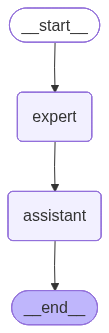

In [7]:
state_graph

In [8]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is class ?")]})

In [9]:
for message in response['messages']:
    print(message.content)

What is class ?
In the realm of software development, a **class** is a fundamental concept, particularly in **Object-Oriented Programming (OOP)**. Think of it as a **blueprint** or a **template** for creating objects. It defines the structure and behavior that objects of that type will have.

Here's a breakdown of what a class is and its key components:

**1. Blueprint/Template:**

*   Imagine you want to build several houses. Instead of designing each house from scratch, you create a blueprint that specifies the number of rooms, the layout, the materials to be used, etc. A class is like that blueprint for creating software objects.

**2. Defines Structure (Attributes/Properties/Fields):**

*   A class specifies the **data** that objects of that class will hold. These are often called **attributes**, **properties**, or **fields**.
*   **Example:** If you have a `Car` class, its attributes might include `color`, `make`, `model`, `year`, and `speed`. Each individual `Car` object created 

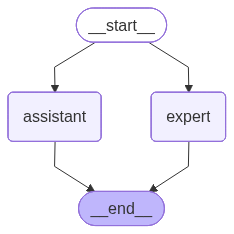

In [10]:
graph = StateGraph(MessagesState)

graph.add_node("expert", node_1)
graph.add_node("assistant", node_2)
graph.set_entry_point("expert")
graph.set_entry_point("assistant")
graph.set_finish_point("assistant")
graph.set_finish_point("expert")
state_graph = graph.compile()
state_graph

In [11]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is class ?")]})

for message in response['messages']:
    print(message.content)

What is class ?
In programming, a **class** is a fundamental concept that serves as a **blueprint** or a **template** for creating objects. It defines the structure and behavior that objects of that class will have.

Think of it like this:

*   **Blueprint for a House:** A house plan (the class) defines how many rooms a house will have, where the doors and windows will be, the materials to be used, etc.
*   **Actual Houses:** When you build a house from that blueprint, you're creating an **object** (an instance of the class). Each house built from the same blueprint will share the same basic structure and features, but they can have different paint colors, furniture, and occupants (different data and states).

Here's a breakdown of the key components and concepts related to classes:

**1. Attributes (or Properties, Data Members, Fields):**
These define the **state** or the **data** that an object will hold. They are like the variables within a class.

*   **Example (Car Class):**
    *

In [12]:
# Sample Structure used 

class ExtendedMessagesState(MessagesState):
    expert_one: str = "Software"
    expert_two: str = "Design"

In [13]:
# Simulate chat bot

def ask_question(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": response}
chat_graph = StateGraph(MessagesState)
chat_graph.add_node("chat", ask_question)
chat_graph.set_entry_point("chat")
chat_graph.set_finish_point("chat")
chat_state_graph = chat_graph.compile()


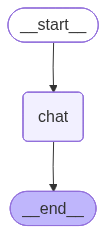

In [14]:
chat_state_graph

In [15]:
# in my state i have list of lenght 1
response = chat_state_graph.invoke({
    "messages": [HumanMessage("What is captial of france?")]
})

len(response['messages'])

2

In [16]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The capital of France is **Paris**.


In [17]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What are good spots in the city")]}
)
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

To give you the **best recommendations for good spots in the city**, I need a little more information! "The city" is a very broad term.

Please tell me:

**1. Which City are you interested in?** (e.g., New York City, London, Tokyo, Paris, your local city)

Once I know the city, I can help you with great spots based on your interests. However, to give you a head start, here are some **general categories of "good spots"** that people often look for, and the kinds of things I'd consider within them:

**General Categories of "Good Spots":**

*   **For Food Lovers:**
    *   **Restaurants:** Fine dining, casual eats, specific cuisines (Italian, Mexican, Thai, etc.), hidden gems, places with great views.
    *   **Cafes/Bakeries:** Cozy spots for coffee and pastries, artisanal coffee shops, places with good brunch.
    *   **Markets:** Food markets, farmers' markets, street food stalls.
*   **For Sightseers & T

In [18]:
config = {"configurable": {"thread_id": "3"}}

response = chat_state_graph.invoke({
    "messages": [HumanMessage("What is captial of france?")]
}, config=config
)


In [19]:
len(response['messages'])

2

In [20]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The capital of France is **Paris**.


In [21]:
response = chat_state_graph.invoke(
    {
        "messages": [HumanMessage(content="What are good spots in this city")]
    },
    config=config
)


In [22]:
len(response['messages'])

2

In [23]:
response['messages']

[HumanMessage(content='What are good spots in this city', additional_kwargs={}, response_metadata={}, id='19c81d54-f04a-4d62-b521-d4b9705d44be'),
 AIMessage(content='To give you the **best** recommendations, I need a little more information! **What city are you interested in?**\n\nOnce you tell me the city, I can give you much more specific and helpful suggestions.\n\nHowever, in the meantime, I can give you some general categories of "good spots" that most cities offer, and you can start thinking about what appeals to you:\n\n**For Culture & History Buffs:**\n\n*   **Museums:** Art museums, history museums, science museums, niche museums (e.g., a specific industry, a famous person).\n*   **Historical Sites:** Landmarks, old buildings, battlefields, ruins, heritage districts.\n*   **Galleries:** Art galleries, photography galleries, independent artist spaces.\n*   **Theaters:** Performing arts centers, independent theaters, opera houses, concert halls.\n\n**For Foodies & Drink Enthusia

In [24]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

To give you the **best** recommendations, I need a little more information! **What city are you interested in?**

Once you tell me the city, I can give you much more specific and helpful suggestions.

However, in the meantime, I can give you some general categories of "good spots" that most cities offer, and you can start thinking about what appeals to you:

**For Culture & History Buffs:**

*   **Museums:** Art museums, history museums, science museums, niche museums (e.g., a specific industry, a famous person).
*   **Historical Sites:** Landmarks, old buildings, battlefields, ruins, heritage districts.
*   **Galleries:** Art galleries, photography galleries, independent artist spaces.
*   **Theaters:** Performing arts centers, independent theaters, opera houses, concert halls.

**For Foodies & Drink Enthusiasts:**

*   **Restaurants:** Fine dining, casual eats, ethnic cuisine, local specialties, farm-to

In [25]:
def response_from_llm(state: MessagesState):
    return {
        "messages": llm.invoke(state["messages"])
    }

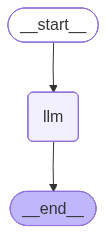

In [26]:
state_learning_graph = StateGraph(MessagesState)
state_learning_graph.add_node("llm", response_from_llm)

state_learning_graph.set_entry_point("llm")
state_learning_graph.set_finish_point("llm")

compiled_state_learning_graph = state_learning_graph.compile()
compiled_state_learning_graph

In [27]:
config = {"configurable": {"thread_id": "1"}}

input_message = HumanMessage(content="Hi this is Ram speaking")
output = compiled_state_learning_graph.invoke(
    {
        "messages": [input_message]
    }, 
    config
)
output['messages'][-1].pretty_print()

================================== Ai Message ==================================

Hi Ram, it's great to hear from you! How can I help you today?


In [28]:
previous_message = output['messages']
previous_message

[HumanMessage(content='Hi this is Ram speaking', additional_kwargs={}, response_metadata={}, id='6285928a-cec1-4368-bb02-e16296124b53'),
 AIMessage(content="Hi Ram, it's great to hear from you! How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d9e74-31a2-7ef0-9cbf-ab1bae79ce4f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 19, 'total_tokens': 24, 'input_token_details': {'cache_read': 0}})]

In [29]:
input_message = HumanMessage(content="What is my name ?")
output = compiled_state_learning_graph.invoke(
    {
        # There is a native way of doing this  => checkpoint, memory and thread
        "messages": previous_message + [input_message]
    }, 
    config
)
output['messages'][-1].pretty_print()

================================== Ai Message ==================================

You just told me! Your name is Ram. 😊


In [30]:
from langgraph.checkpoint.memory import InMemorySaver

memory_enabled_graph = state_learning_graph.compile(
    checkpointer=InMemorySaver()
)

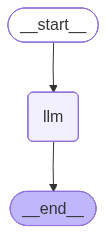

In [31]:
memory_enabled_graph

In [32]:
user1_config = {"configurable": {"thread_id": "1"}}
user2_config = {"configurable": {"thread_id": "2"}}

In [33]:
# user 1 conversations
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="Hi this is Ram")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

================================== Ai Message ==================================

Hi Ram, nice to meet you! How can I help you today?
length = 2


In [34]:
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="I live in Hyderabad")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

================================== Ai Message ==================================

That's great! Hyderabad is a fantastic city. I've heard it's known for its rich history, delicious food (especially biryani!), and vibrant culture.

What brings you to Hyderabad, or what's on your mind regarding the city? Are you looking for information, recommendations, or just chatting?
length = 4


In [35]:
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="I live in Ameerpet")]
    },
    user1_config
)
print(f"length = {len(response['messages'])}")

length = 6


In [36]:
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

================================== Ai Message ==================================

Ameerpet! That's a very well-known area in Hyderabad, especially for its IT training institutes. It's a buzzing hub of activity.

How do you like living in Ameerpet? Is it convenient for you?
length = 6


In [37]:
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="Where do i live in Mumbai ?")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")


================================== Ai Message ==================================

That's a fun question! Since I'm an AI, I don't have access to your personal information, including where you live. I don't know your location or any details about you.

So, to answer your question: **I don't know where you live in Mumbai.**

If you'd like to tell me, I'd be happy to hear it!
length = 8


In [38]:
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="What is my name ?")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")
my_state = MessagesState(
    messages = response['messages']
)

================================== Ai Message ==================================

You told me your name is Ram at the beginning of our conversation.
length = 10


In [39]:
# user 2
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="What is my name")]
    },
    user2_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

================================== Ai Message ==================================

I do not have access to your personal information, including your name. I am a large language model, and my purpose is to provide information and complete tasks neutrally and objectively. I do not store or recall user data.
length = 2


In [40]:
def summarize(state: MessagesState):
    messages = state["messages"]
    response = llm.invoke([
        SystemMessage(content="Summarize the conversation"),
        *messages
    ])
    return response['messages']
    


In [41]:
messages = summarize(my_state)

TypeError: 'AIMessage' object is not subscriptable

In [ ]:
len(messages)

10

In [ ]:
messages[-1].pretty_print()

================================== Ai Message ==================================

Your name is **Ram**. You told me that at the very beginning of our conversation! 😊


In [75]:
from langgraph.runtime import Runtime
from langgraph.store.memory import InMemoryStore


class StudentState(MessagesState):
    name: str
    email: str
    dept: str


def process_student_info(state: StudentState, runtime: Runtime):
    content= f"Student {state['name']} from {state['dept']} has email {state['email']}"
    if True:
        # retrieving from long term memory
        preference = runtime.store.get(
            namespace=("students",state['name'], "preference"),
            key="preference",
        )
        if preference:
            content += f" and prefers {preference}"


    return {
        "messages": llm.invoke(
            [
                SystemMessage(content="You are helpful student advisor, Act as an employee of Delhi University"),
                HumanMessage(
                    content=content),
                *state['messages']
            ]
        )
    }

def evaluate_result(state: StudentState, runtime: Runtime):
    if True:
        # storing in long term memory
        runtime.store.put(
            namespace=("students",state['name'], "preference"),
            key="preference",
            value=response['messages'][-1].content
        )
    return state

In [76]:
student_graph_builder = StateGraph(StudentState)

student_graph_builder.add_node("process", process_student_info)
student_graph_builder.add_node("evaluate", evaluate_result)

student_graph_builder.set_entry_point("process")
student_graph_builder.add_edge("process", "evaluate")
student_graph_builder.set_finish_point("evaluate")

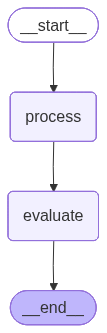

In [77]:
# compile the graph
student_graph = student_graph_builder.compile(
    checkpointer=InMemorySaver(),
    store=InMemoryStore()
)

student_graph

In [78]:
student1_config = {"configurable": {"thread_id": "1"}}
student2_config = {"configurable": {"thread_id": "2"}}


response = student_graph.invoke(
    {
        "name": "Ram",
        "email": "ram@gmail.com",
        "dept": "commerce",
        "messages": [
            HumanMessage(content="I want to know Sports Activities, As i like football")]
    },
    config=student1_config
)

In [79]:
def print_all_messages(messages: list[BaseMessage]):
    for message in messages:
        message.pretty_print()


In [80]:
print_all_messages(response['messages'])

================================ Human Message =================================

I want to know Sports Activities, As i like football
================================== Ai Message ==================================

Hello Ram,

It's great to hear from you! I'm happy to assist you with information about sports activities at Delhi University, especially since you're interested in football.

Delhi University has a very vibrant sports culture, and there are numerous opportunities for students to participate, train, and compete. Here's a breakdown of what you can expect regarding sports activities, with a focus on football:

**1. Inter-College Competitions:**

*   **Football is a major sport** at Delhi University, and almost every college has its own football team.
*   There are regular **inter-college tournaments** organized throughout the academic year. These range from league matches to knockout stages, culminating in university-level championships.
*   Representing your college in thes

In [82]:
response = student_graph.invoke(
    {
        "name": "Ram",
        "email": "ram@gmail.com",
        "dept": "commerce",
        "messages": [
            HumanMessage(
                content="What do i like ?"
            )
        ]
    },
    config=student1_config
)
print_all_messages(response['messages'])


================================ Human Message =================================

I want to know Sports Activities, As i like football
================================== Ai Message ==================================

Hello Ram,

It's great to hear from you! I'm happy to assist you with information about sports activities at Delhi University, especially since you're interested in football.

Delhi University has a very vibrant sports culture, and there are numerous opportunities for students to participate, train, and compete. Here's a breakdown of what you can expect regarding sports activities, with a focus on football:

**1. Inter-College Competitions:**

*   **Football is a major sport** at Delhi University, and almost every college has its own football team.
*   There are regular **inter-college tournaments** organized throughout the academic year. These range from league matches to knockout stages, culminating in university-level championships.
*   Representing your college in thes